In [1]:
print("hi")

hi


In [6]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI

In [7]:
from typing import TypedDict
from dotenv import load_dotenv

In [8]:
import os
load_dotenv(override=True)

True

In [9]:
def get_groq_llm():
    return ChatOpenAI(
        model= "openai/gpt-oss-120b",
        base_url= "https://api.groq.com/openai/v1",
        api_key= os.getenv("GROQ_API_KEY"),
        max_tokens= 1000
    )

In [10]:
llm= get_groq_llm()

In [11]:
class LLMState(TypedDict):
    question: str
    answer: str

In [14]:
def chat_llm(state: LLMState):

    question= state['question']

    ##prompt:
    prompt= f'Answer the following Question {question}'

    answer= llm.invoke(prompt).content
    
    state['answer']= answer

    return state


    


In [15]:
graph= StateGraph(LLMState)

## add nodes

graph.add_node('chat_llm',chat_llm)

In [16]:
## add edges

graph.add_edge(START,'chat_llm')
graph.add_edge('chat_llm', END)

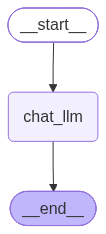

In [17]:
workflow= graph.compile()

workflow

In [18]:
intial_state= {'question':'How far is the moon from earth'}

final_state= workflow.invoke(intial_state)

print(final_state)

{'question': 'How far is the moon from earth', 'answer': 'The Moon orbits Earth at an average distance of **about\u202f384,400\u202fkilometers (≈\u202f238,900\u202fmiles)**.\n\n- **Perigee (closest point)**: ≈\u202f363,300\u202fkm (≈\u202f225,600\u202fmi)  \n- **Apogee (farthest point)**: ≈\u202f405,500\u202fkm (≈\u202f251,900\u202fmi)\n\nThese values are averages; the actual distance varies slightly because the Moon’s orbit is elliptical and is also affected by the gravitational pull of the Sun and other bodies. If you need the distance at a specific date and time, astronomical almanacs or online tools (e.g., NASA’s JPL Horizons system) can provide the precise instantaneous distance.'}


In [19]:
print(final_state['answer'])

The Moon orbits Earth at an average distance of **about 384,400 kilometers (≈ 238,900 miles)**.

- **Perigee (closest point)**: ≈ 363,300 km (≈ 225,600 mi)  
- **Apogee (farthest point)**: ≈ 405,500 km (≈ 251,900 mi)

These values are averages; the actual distance varies slightly because the Moon’s orbit is elliptical and is also affected by the gravitational pull of the Sun and other bodies. If you need the distance at a specific date and time, astronomical almanacs or online tools (e.g., NASA’s JPL Horizons system) can provide the precise instantaneous distance.


In [ ]:
intial_state= {'question':'okay great but how far from Sun?'}

final_state= workflow.invoke(intial_state)

In [21]:
print(final_state)

{'question': 'okay great but how far from Sun?', 'answer': 'The distance from the Sun to a planet (or any object) is usually expressed in **Astronomical Units (AU)**, where 1\u202fAU\u202f≈\u202f149.6\u202fmillion\u202fkm (≈\u202f93\u202fmillion\u202fmiles).  \n\n### Earth\n- **Average distance:** ~1\u202fAU ≈ **149.6\u202fmillion\u202fkm** (≈\u202f93\u202fmillion\u202fmi)  \n- **Range over a year:** 147\u202fmillion\u202fkm (perihelion, early January)\u202f–\u202f152\u202fmillion\u202fkm (aphelion, early July)  \n\n### Quick reference for the other planets  \n\n| Planet | Average distance from the Sun (AU) | Average distance (km) |\n|--------|-----------------------------------|-----------------------|\n| Mercury | 0.39\u202fAU | 58\u202fmillion\u202fkm |\n| Venus   | 0.72\u202fAU | 108\u202fmillion\u202fkm |\n| Earth   | 1.00\u202fAU | 149.6\u202fmillion\u202fkm |\n| Mars    | 1.52\u202fAU | 228\u202fmillion\u202fkm |\n| Jupiter | 5.20\u202fAU | 778\u202fmillion\u202fkm |\n| Saturn  

In [22]:
print(final_state['answer'])


The distance from the Sun to a planet (or any object) is usually expressed in **Astronomical Units (AU)**, where 1 AU ≈ 149.6 million km (≈ 93 million miles).  

### Earth
- **Average distance:** ~1 AU ≈ **149.6 million km** (≈ 93 million mi)  
- **Range over a year:** 147 million km (perihelion, early January) – 152 million km (aphelion, early July)  

### Quick reference for the other planets  

| Planet | Average distance from the Sun (AU) | Average distance (km) |
|--------|-----------------------------------|-----------------------|
| Mercury | 0.39 AU | 58 million km |
| Venus   | 0.72 AU | 108 million km |
| Earth   | 1.00 AU | 149.6 million km |
| Mars    | 1.52 AU | 228 million km |
| Jupiter | 5.20 AU | 778 million km |
| Saturn  | 9.58 AU | 1.43 billion km |
| Uranus  | 19.2 AU | 2.87 billion km |
| Neptune | 30.1 AU | 4.50 billion km |
| Pluto* | 39.5 AU | 5.91 billion km |

\*Pluto is classified as a dwarf planet.

If you had a specific object in mind (a spacecraft, a part

## Call to llm:
## Stateless Calls: It does not have any previous message history



##

User_query_no1: hsxbshbxh
llm: hsxbhjsxhbv

user_q2: follow up question
llm: proper answe

## sending all prev, info to llm